## Useful Links

1.   https://numba.pydata.org/numba-doc/dev/user/5minguide.html
2.   https://github.com/jacobtomlinson/gpu-python-tutorial/tree/main
3.   https://github.com/ContinuumIO/gtc2017-numba



### Installation just in case not available in your environment

In [ ]:
!pip install numba

In [ ]:
!nvidia-smi

Mon Apr 28 06:38:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

## Hello World

In [ ]:
from numba import jit
import numpy as np
import time

x = np.arange(100).reshape(10, 10)

def cpu(a):
    trace = 0.0
    for i in range(a.shape[0]):
        trace += np.tanh(a[i, i])
    return a + trace

@jit(nopython=True)
def cpu_native(a):
    trace = 0.0
    for i in range(a.shape[0]):
        trace += np.tanh(a[i, i])
    return a + trace


start = time.time()
cpu(x)
end = time.time()
print("Elapsed CPU = %s" % (end - start))

# DO NOT REPORT THIS... COMPILATION TIME IS INCLUDED IN THE EXECUTION TIME!
start = time.time()
cpu_native(x)
end = time.time()
print("Elapsed CPU Native (with compilation) = %s" % (end - start))

# NOW THE FUNCTION IS COMPILED, RE-TIME IT EXECUTING FROM CACHE
start = time.time()
cpu_native(x)
end = time.time()
print("Elapsed CPU Native (after compilation) = %s" % (end - start))

Elapsed CPU = 0.00016570091247558594
Elapsed CPU Native (with compilation) = 1.209123134613037
Elapsed CPU Native (after compilation) = 9.226799011230469e-05


## Vector Add

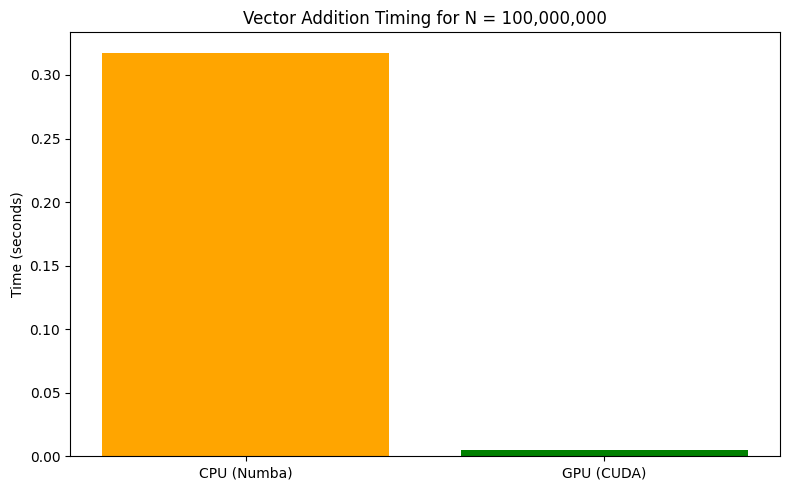

In [ ]:
import numpy as np
import time
from numba import cuda, njit
import matplotlib.pyplot as plt

# Problem size
N = 100_000_000

# Host arrays
a = np.ones(N, dtype=np.float32)
b = np.ones(N, dtype=np.float32)
c_cpu = np.zeros(N, dtype=np.float32)
c_gpu = np.zeros(N, dtype=np.float32)

# --------------------------------
@njit
def vector_add_cpu(a, b, out):
    for i in range(a.size):
        out[i] = a[i] + b[i]

# --------------------------------
@cuda.jit
def vector_add_gpu(a, b, out):
    i = cuda.grid(1)
    if i < a.size:
        out[i] = a[i] + b[i]

# CPU timing
start_cpu = time.time()
vector_add_cpu(a, b, c_cpu)
end_cpu = time.time()
cpu_time = end_cpu - start_cpu

# GPU setup
d_a = cuda.to_device(a)
d_b = cuda.to_device(b)
d_c = cuda.device_array_like(a)

threads_per_block = 256
blocks_per_grid = (a.size + threads_per_block - 1) // threads_per_block

# Warm-up run
vector_add_gpu[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
cuda.synchronize()

# GPU timing
start_gpu = time.time()
vector_add_gpu[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
cuda.synchronize()
end_gpu = time.time()
gpu_time = end_gpu - start_gpu

# Copy result back
d_c.copy_to_host(c_gpu)

# Verify
assert np.allclose(c_cpu, c_gpu)

# --------------------------------
# Plot
labels = ['CPU (Numba)', 'GPU (CUDA)']
times = [cpu_time, gpu_time]

plt.figure(figsize=(8, 5))
plt.bar(labels, times, color=['orange', 'green'])
plt.title(f"Vector Addition Timing for N = {N:,}")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()

## Matrix Operations

In [ ]:
import numpy as np

# Create two matrices (e.g., 3x3)
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

B = np.array([[9, 8, 7],
              [6, 5, 4],
              [3, 2, 1]])

# Matrix addition
C = A + B

print("Matrix A:\n", A)
print("Matrix B:\n", B)
print("Sum (A + B):\n", C)


Matrix A:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Matrix B:
 [[9 8 7]
 [6 5 4]
 [3 2 1]]
Sum (A + B):
 [[10 10 10]
 [10 10 10]
 [10 10 10]]


In [ ]:
from numba import njit

@njit
def add_matrices(A, B):
    rows, cols = A.shape
    C = np.zeros((rows, cols), dtype=A.dtype)
    for i in range(rows):
        for j in range(cols):
            C[i, j] = A[i, j] + B[i, j]
    return C

# Use same A and B from above
C_numba = add_matrices(A, B)
print("Sum using Numba:\n", C_numba)


Sum using Numba:
 [[10 10 10]
 [10 10 10]
 [10 10 10]]


## Gaussian Blur

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from numba import cuda
import numpy as np
import math

plt.rcParams["figure.figsize"] = (30,4)

In [ ]:
!wget https://raw.githubusercontent.com/jacobtomlinson/gpu-python-tutorial/main/images/numba.png
im = plt.imread("numba.png")

--2025-05-02 19:27:51--  https://raw.githubusercontent.com/jacobtomlinson/gpu-python-tutorial/main/images/numba.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3809 (3.7K) [image/png]
Saving to: ‘numba.png’

numba.png           100%[===================>]   3.72K  --.-KB/s    in 0s      

2025-05-02 19:27:51 (68.2 MB/s) - ‘numba.png’ saved [3809/3809]



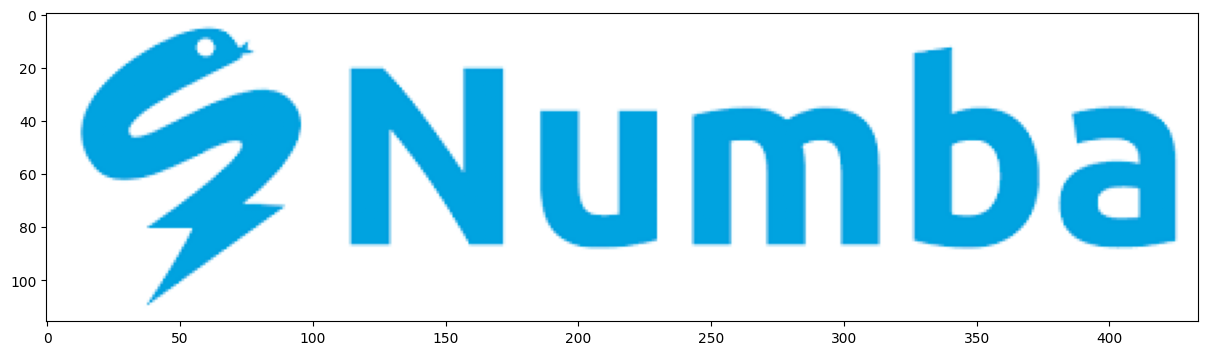

In [ ]:
plt.imshow(im)

In [ ]:
type(im)

numpy.ndarray

In [ ]:
im.shape

(116, 434, 4)

In [ ]:
gpu_im = cuda.to_device(im)
cpu_output = np.zeros_like(im)
gpu_output = cuda.to_device(np.zeros_like(gpu_im))

In [ ]:
# threadsperblock = 128
threadsperblock = (2, 16, 4)

In [ ]:
blockspergrid_x = math.ceil(gpu_im.shape[0] / threadsperblock[0])
blockspergrid_y = math.ceil(gpu_im.shape[1] / threadsperblock[1])
blockspergrid_z = math.ceil(gpu_im.shape[2] / threadsperblock[2])
blockspergrid = (blockspergrid_x, blockspergrid_y, blockspergrid_z)

In [ ]:
blockspergrid

(58, 28, 1)

In [ ]:
import numpy as np

def blur_cpu(im, output):
    height, width, channels = im.shape
    for x in range(1, height - 1):
        for y in range(1, width - 1):
            for c in range(channels):
                output[x, y, c] = (
                    im[x-1, y-1, c] + im[x, y-1, c] + im[x+1, y-1, c] +
                    im[x-1, y, c]   + im[x, y, c]   + im[x+1, y, c]   +
                    im[x-1, y+1, c] + im[x, y+1, c] + im[x+1, y+1, c]
                ) / 9

In [ ]:
blur_cpu(im, cpu_output)

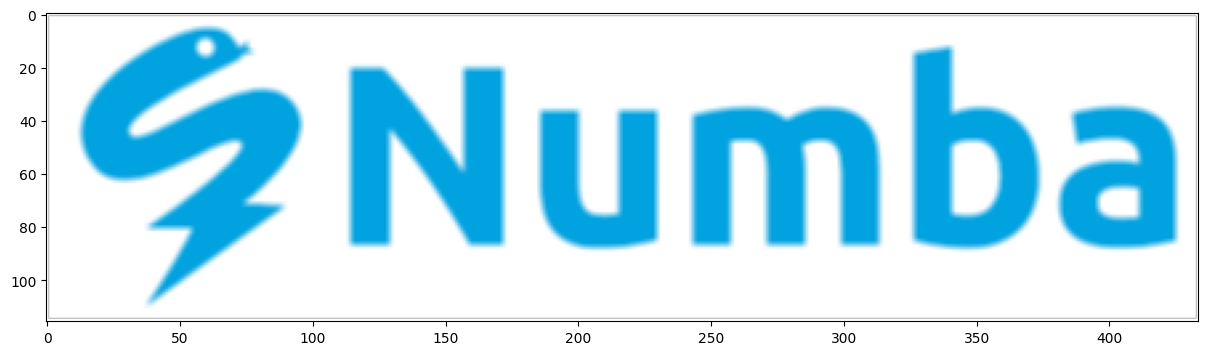

In [ ]:
plt.imshow(cpu_output)

In [ ]:
@cuda.jit
def blur_gpu(im, output):
    # With our three-dimensional grid we can get our index position in three dimensions
    x, y, c = cuda.grid(3)

    # Because our grid is slightly larger than our image anything outside the image should be ignored
    if x < im.shape[0] and y < im.shape[1] and c < im.shape[2]:

        # Set the output array pixel to the average of the nine pixels around that point on the input array
        output[x, y, c] = (im[x-1, y-1, c] + im[x, y-1, c] + im[x+1, y-1, c]  + \
                           im[x-1, y, c]   + im[x, y, c]   + im[x+1, y, c]    + \
                           im[x-1, y+1, c] + im[x+1, y, c] + im[x+1, y+1, c]) / 9

NameError: name 'cuda' is not defined

In [ ]:
@cuda.jit
def blur_gpu_shared(im, output):
    # Get thread and block indices
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    bx = cuda.blockIdx.x
    by = cuda.blockIdx.y
    bw = cuda.blockDim.x
    bh = cuda.blockDim.y

    # Global image coordinates
    x = bx * bw + tx
    y = by * bh + ty

    # Shared memory tile size (with 1-pixel padding on each side)
    # assuming blockDim=16 and RGB (3 channels)
    shared = cuda.shared.array(shape=(18, 18, 3), dtype=np.uint8) # dtype=cuda.uint8

    for c in range(3):  # Loop over RGB channels
        # Load into shared memory (with 1 pixel halo)
        if x < im.shape[0] and y < im.shape[1]:
            shared[tx+1, ty+1, c] = im[x, y, c]

            # Load halo pixels
            if tx == 0 and x > 0:
                shared[0, ty+1, c] = im[x-1, y, c]
            if tx == bw - 1 and x < im.shape[0] - 1:
                shared[tx+2, ty+1, c] = im[x+1, y, c]
            if ty == 0 and y > 0:
                shared[tx+1, 0, c] = im[x, y-1, c]
            if ty == bh - 1 and y < im.shape[1] - 1:
                shared[tx+1, ty+2, c] = im[x, y+1, c]

            # Corners
            if tx == 0 and ty == 0 and x > 0 and y > 0:
                shared[0, 0, c] = im[x-1, y-1, c]
            if tx == 0 and ty == bh - 1 and x > 0 and y < im.shape[1] - 1:
                shared[0, ty+2, c] = im[x-1, y+1, c]
            if tx == bw - 1 and ty == 0 and x < im.shape[0] - 1 and y > 0:
                shared[tx+2, 0, c] = im[x+1, y-1, c]
            if tx == bw - 1 and ty == bh - 1 and x < im.shape[0] - 1 and y < im.shape[1] - 1:
                shared[tx+2, ty+2, c] = im[x+1, y+1, c]

    cuda.syncthreads()

    # Now compute blur if within valid bounds
    if 1 <= x < im.shape[0] - 1 and 1 <= y < im.shape[1] - 1:
        for c in range(3):
            val = (
                shared[tx, ty, c]     + shared[tx+1, ty, c]     + shared[tx+2, ty, c] +
                shared[tx, ty+1, c]   + shared[tx+1, ty+1, c]   + shared[tx+2, ty+1, c] +
                shared[tx, ty+2, c]   + shared[tx+1, ty+2, c]   + shared[tx+2, ty+2, c]
            ) // 9
            output[x, y, c] = val


In [ ]:
for i in range(5):
    blur_gpu[blockspergrid, threadsperblock](gpu_im, gpu_output)
    gpu_im, gpu_output = gpu_output, gpu_im

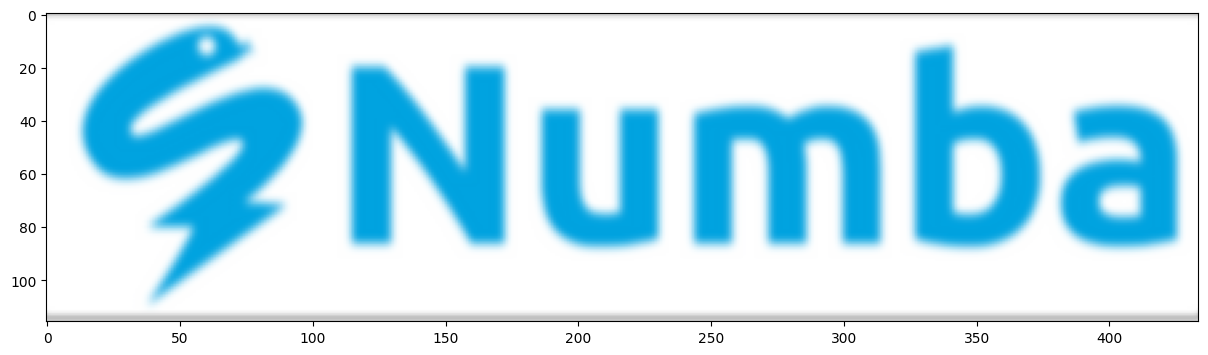

In [ ]:
plt.imshow(gpu_output.copy_to_host())

## RGB to Grayscal Conversion

### RGB to Grayscale Conversion

To convert an RGB image to Grayscale, we apply a weighted sum of the Red, Green, and Blue channels.

Grayscale = 0.299 R + 0.587 G + 0.114 B
- R: Red channel intensity  
- G: Green channel intensity  
- B: Blue channel intensity  


In [ ]:
import numpy as np
from numba import njit

@njit
def rgb_to_grayscale_cpu(image):
    height, width, _ = image.shape
    grayscale_image = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            r, g, b = image[i, j]
            grayscale_image[i, j] = int(0.299 * r + 0.587 * g + 0.114 * b)
    return grayscale_image

In [ ]:
@cuda.jit
def rgb_to_grayscale_gpu(image, grayscale_image):
    i, j = cuda.grid(2)
    if i < image.shape[0] and j < image.shape[1]:
        r, g, b = image[i, j]
        grayscale_image[i, j] = int(0.299 * r + 0.587 * g + 0.114 * b)

In [ ]:
import math
import numpy as np

# Test images
test_image_small = np.random.randint(0, 256, size=(128, 128, 3), dtype=np.uint8)
test_image_large = np.random.randint(0, 256, size=(1024, 1024, 3), dtype=np.uint8)


def test_rgb_to_grayscale(func, image, label):
    start_time = time.time()
    grayscale_image = func(image)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"{label} execution time: {elapsed_time:.4f} seconds")
    # You might add assertions here to verify the results if you have ground truth data
    return elapsed_time, grayscale_image


# CPU tests
cpu_small_time, cpu_small_gray = test_rgb_to_grayscale(rgb_to_grayscale_cpu, test_image_small, "CPU Small")
cpu_large_time, cpu_large_gray = test_rgb_to_grayscale(rgb_to_grayscale_cpu, test_image_large, "CPU Large")


# GPU tests
d_image_small = cuda.to_device(test_image_small)
d_grayscale_small = cuda.device_array_like(rgb_to_grayscale_cpu(test_image_small))  # Changed line

threads_per_block = (16, 16)
blocks_per_grid_x = math.ceil(test_image_small.shape[0] / threads_per_block[0])
blocks_per_grid_y = math.ceil(test_image_small.shape[1] / threads_per_block[1])
blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

gpu_small_time, gpu_small_gray = test_rgb_to_grayscale(
    lambda x: rgb_to_grayscale_gpu[blocks_per_grid, threads_per_block](d_image_small, d_grayscale_small) or d_grayscale_small.copy_to_host(),
    test_image_small, "GPU Small"
)


# Adjust block and grid sizes for the larger image
threads_per_block = (16, 16)
blocks_per_grid_x = math.ceil(test_image_large.shape[0] / threads_per_block[0])
blocks_per_grid_y = math.ceil(test_image_large.shape[1] / threads_per_block[1])
blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

d_image_large = cuda.to_device(test_image_large)
d_grayscale_large = cuda.device_array_like(rgb_to_grayscale_cpu(test_image_large))

gpu_large_time, gpu_large_gray = test_rgb_to_grayscale(
    lambda x: rgb_to_grayscale_gpu[blocks_per_grid, threads_per_block](d_image_large, d_grayscale_large) or d_grayscale_large.copy_to_host(),
    test_image_large, "GPU Large"
)


print("CPU small / GPU small:", cpu_small_time / gpu_small_time)
print("CPU large / GPU large:", cpu_large_time / gpu_large_time)


CPU Small execution time: 0.0001 seconds
CPU Large execution time: 0.0022 seconds
GPU Small execution time: 0.0006 seconds
GPU Large execution time: 0.0006 seconds
CPU small / GPU small: 0.09200310559006211
CPU large / GPU large: 3.388392857142857


/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/dispatcher.py:579: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


## Mandlebrot set

The Mandelbrot set is a two-dimensional set that is defined in the complex  plane as the complex numbers c for which the function $f_c(z) = z^2 + c$ does not diverge to infinity when iterated starting at $z=0$.

CPU time: 0.7221 s


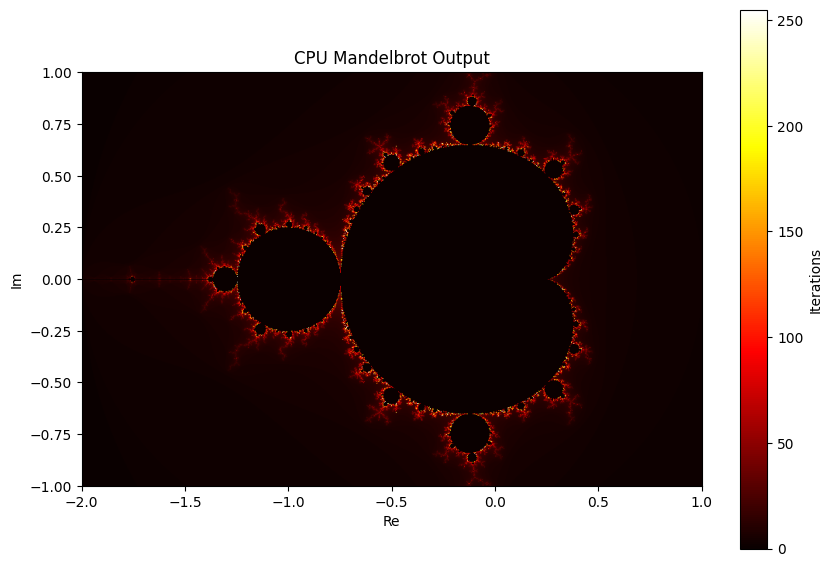

GPU time: 0.1226 s


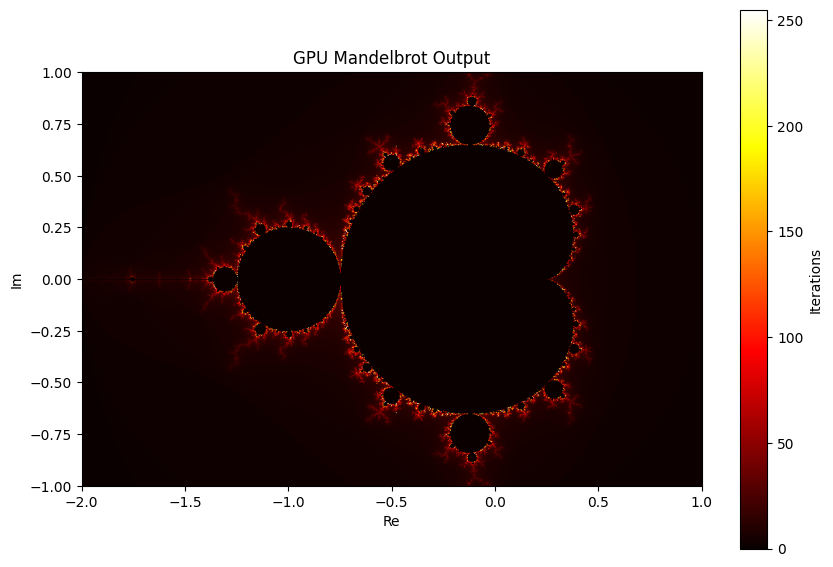

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from numba import cuda, njit, jit

# Parameters
WIDTH = 800
HEIGHT = 600
MAX_ITER = 400

# Bounds
RE_START = -2.0
RE_END = 1.0
IM_START = -1.0
IM_END = 1.0

# CPU implementation
# @jit
# @jit(nopython=True)
@njit
def mandelbrot_cpu(width, height, max_iter):
    image = np.zeros((height, width), dtype=np.uint8)
    for x in range(width):
        for y in range(height):
            re = RE_START + (x / width) * (RE_END - RE_START)
            im = IM_START + (y / height) * (IM_END - IM_START)
            c = complex(re, im)
            z = 0.0j
            for i in range(max_iter):
                z = z*z + c
                if abs(z) > 2.0:
                    image[y, x] = i; #np.clip(i, 0, 255)
                    break
    return image

# GPU implementation
@cuda.jit
def mandelbrot_gpu(image, width, height, max_iter, re_start, re_end, im_start, im_end):
    x, y = cuda.grid(2)
    if x < width and y < height:
        re = re_start + (x / width) * (re_end - re_start)
        im = im_start + (y / height) * (im_end - im_start)
        c = complex(re, im)
        z = 0.0j
        for i in range(max_iter):
            z = z*z + c
            if abs(z) > 2.0:
                image[y, x] = i
                break

# Display function
def display_image(image, title="Mandelbrot"):
    plt.figure(figsize=(10, 7))
    plt.imshow(image, cmap='hot', extent=(RE_START, RE_END, IM_START, IM_END))
    plt.title(title)
    plt.xlabel("Re")
    plt.ylabel("Im")
    plt.colorbar(label="Iterations")
    plt.show()

# Main execution
if __name__ == '__main__':
    # CPU
    start_cpu = time.time()
    img_cpu = mandelbrot_cpu(WIDTH, HEIGHT, MAX_ITER)
    end_cpu = time.time()
    print(f"CPU time: {end_cpu - start_cpu:.4f} s")
    display_image(img_cpu, title="CPU Mandelbrot Output")

    # GPU
    image_gpu = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)
    d_image = cuda.to_device(image_gpu)

    threadsperblock = (16, 16)
    blockspergrid_x = (WIDTH + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (HEIGHT + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    start_gpu = time.time()
    mandelbrot_gpu[blockspergrid, threadsperblock](d_image, WIDTH, HEIGHT, MAX_ITER, RE_START, RE_END, IM_START, IM_END)
    image_gpu = d_image
    end_gpu = time.time()
    print(f"GPU time: {end_gpu - start_gpu:.4f} s")
    display_image(image_gpu, title="GPU Mandelbrot Output")
